In [1]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

from scipy.linalg import block_diag
import scipy as sc
import sympy as sp


import rover as rover_class
import grid_world
from astar_plan import AStarPlanner

In [2]:
# set-up orbit epoch, number of satellites, number of planes, and number of satellites per plane
epoch_0 = pnt.SpiceInterface.string_to_tai("2025/10/02 00:00:00.000 UTC")
N_sat = 4
N_planes = 2
N_sat_plane = N_sat // N_planes
# Classical orbital elements (a, e, i, W, w, M) [km, -, rad, rad, rad, rad]
sma = 6142.4  # [km] Semi-major axis
ecc = [0.6, 0.6]  # [-] Eccentricity
inc = np.deg2rad([57.7, 57.7])  # [rad] Inclination
raan = np.deg2rad([0, 180])  # [rad] Right ascension of the ascending node
aop = np.deg2rad([90, 90])  # [rad] Argument of periapsis
ma = np.deg2rad([180, 0])  # [rad] Mean anomaly

# group the together and create the initial state vectors
coe_mi = np.zeros((N_sat, 6))
rv0_moon_sat_mi = np.zeros((N_sat, 6))
for i_pl in range(N_planes):
    for i_spl in range(N_sat_plane):
        i_sat = i_pl * N_sat_plane + i_spl
        coe_mi[i_sat] = np.array(
            [sma, ecc[i_pl], inc[i_pl], raan[i_pl], aop[i_pl], ma[i_spl]]
        )
        rv0_moon_sat_mi[i_sat] = pnt.classical_to_cartesian(coe_mi[i_sat], pnt.MU_MOON)

# Time discretization
# TODO: this is where we can change things up depending on the simulation scenario
sma = coe_mi[0, 0]  # [km] Semi-major axis
period = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)  # [s] Orbital period
Dt = 5 * pnt.SECS_PER_MINUTE  # [s] Simulation time step
dt = 5 * pnt.SECS_PER_MINUTE  # [s] Propagation time step
# NOTE: 3 days of simulation time takes 2 minutes and 36 seconds of computation time with the current time step
N_days = 2  # [-] Number of days
tf = N_days * pnt.SECS_PER_DAY  # [s] Simulation final time
N_t = int(tf / Dt)  # [-] Number of time steps
tspan = np.linspace(0, tf, N_t)  # [s] Time since first epoch
epochs = epoch_0 + tspan  # [s] Epochs (TAI)

# Dynamics (three-body with Earth, no Sun included)
dynamics = pnt.NBodyDynamics()
dynamics.set_primary_body(pnt.Body.Moon())
# dynamics.add_body(pnt.Body.Earth())
dynamics.set_time_step(dt)

# Propagation
# rv_{from}_{to}_{frame} [km, km/s] (x, y, z, vx, vy, vz)
rv_moon_sat_mi = np.zeros((N_sat, N_t, 6))
rv_moon_sat_pa = np.zeros((N_sat, N_t, 6))
for i_sat in range(N_sat):
    rv_moon_sat_mi[i_sat] = dynamics.propagate(rv0_moon_sat_mi[i_sat], epoch_0, epochs)
    rv_moon_sat_pa[i_sat] = pnt.CoordConverter.convert(
        epochs, rv_moon_sat_mi[i_sat], pnt.MI, pnt.PA
    )


Loaded All SPICE Kernels
Loaded Chebyshev coefficients for 14 planets.


## Save the satellite positions as a csv file

In [3]:
# save the satellite positions as a csv file
for i_sat in range(N_sat):
    df = pd.DataFrame(rv_moon_sat_pa[i_sat])
    #set the column names
    df.columns = ["x", "y", "z", "vx", "vy", "vz"]
    # add a time column at the beginning
    df.insert(0, "time", tspan)
    df.to_csv(f"data/sat_{i_sat}.csv", index=False, header=True)


In [4]:
def get_pseudorange_measurement(satpos, x_est, use_Gnoise):
    # simulate pseudorange measurements from a given satellite
    # likely inputs: true satellite state, true receiver state
    # we can already add noise to the measurements here, or outside like in the MATLAB simulator
    # the pseudorange error model is the same as what we had from the endurance work
    # also let's get the Jacobian here too (maybe JAX can come in handy!)
    
    # x_est is a 1x3 np array and satpos is a Nx3 np array
    n_meas = satpos.shape[0]
    los = np.tile(x_est, (n_meas, 1)) - satpos # Nx3
    range = np.linalg.norm(los, axis=1) # 1xN
    # Added simple Gaussian noise model
    if use_Gnoise:
        Gnoise = np.random.normal(0.0, 1.0, size=n_meas)
        range += Gnoise
    # print('los = ', los)
    # print('range = ', range)
    e = los / np.tile(range, (3, 1)).T # Nx3
    H = e
    return range, H

def get_pseudorange_rate_measurement():
    # simulate pseudorange rate measurements from a given satellite
    # now the error model for this... is a little different and we need to think about it more
    # plus we need this for the ION paper too
    raise NotImplementedError

def get_CN0(dist_m, EIRP_beta_dBW, rec_gain_theta_dBi, fcar=2492.028e6, LNA_NF_dB = 1, rec_Tsys_K = 113):
    # assume that the satellite is always pointing towards the center of the moon
    # we are going to need some antenna gain patterns for this, but we can fish them out from the MATLAB simulator
    # simulate the carrier-to-noise ratio for a given satellite
    c = 299792458
    k_dBW_K_Hz = -228.6
    FSPL_dB = 20*np.log10(4*np.pi*dist_m*fcar/c)
    Prx = EIRP_beta_dBW - FSPL_dB
    Teq_K = rec_Tsys_K + 290*(10**(LNA_NF_dB/10)-1)
    Teq_dB = 10*np.log10(Teq_K)
    g_over_T = rec_gain_theta_dBi - Teq_dB
    cn0_dBHz = Prx + g_over_T - k_dBW_K_Hz
    # cn0 = 10**(cn0_dBHz/10) # Hz
    return cn0_dBHz

def mcmf_to_enu(lat_user, lon_user):
    # convert from MCMF to ENU coordinates
    # lat_user = rover latitude in radians (1x1)
    # lon_user = rover longitude in radians (1x1)
    phi, lmda = lat_user, lon_user
    M = np.array([
        [-np.sin(lmda), np.cos(lmda), 0],
        [-np.cos(lmda)*np.sin(phi), -np.sin(lmda)*np.sin(phi), np.cos(phi)],
        [np.cos(lmda)*np.cos(phi), np.sin(lmda)*np.cos(phi), np.sin(phi)]
    ])
    return M
    
def get_elev_azim(M, mcmf_sat, user_mcmf_rv):
    # get the elevation and azimuth of a given satellite (VALIDATED WITH PATHFINDER ORBIT)
    # M = output of mcmf_to_enu function (6x6)
    # mcmf_sat = Nx6 state vector of satellite (N is number of satellites)
    # user_mcmf_rv = 1x6 state vector of rover

    # note that mcmf_sat is a N_sat X N_time X x 6 array
    lent = mcmf_sat.shape[1]
    enu_sat = np.zeros(mcmf_sat.shape)
    el_sat, az_sat = np.zeros((mcmf_sat.shape[0], lent)), np.zeros((mcmf_sat.shape[0], lent))

    for sat_idx in range(mcmf_sat.shape[0]):
        for t in range(mcmf_sat.shape[1]):  
            enu_sat[sat_idx, t, :] = block_diag(M, M) @ (mcmf_sat[sat_idx,t,:] - user_mcmf_rv)
            norm_enu_sat = np.linalg.norm(enu_sat[sat_idx, t, :3])

            el_sat[sat_idx,t] = np.degrees(np.arcsin(enu_sat[sat_idx, t, 2] / norm_enu_sat))  # up

            norm_east, norm_north = enu_sat[sat_idx, t, 0] / norm_enu_sat, enu_sat[sat_idx, t, 1] / norm_enu_sat
            az_sat_rad = np.mod(np.arctan2(norm_east, norm_north), 2 * np.pi)
            az_sat[sat_idx, t] = np.degrees(az_sat_rad)

    return el_sat, az_sat


In [5]:
# rover
# assume the user is at the Poincare crater (in rad)
lat_user = np.deg2rad(-59.12448)
lon_user = np.deg2rad(161.05104)

# assume the user is at the Poincare crater (in rad)
lat_user = np.deg2rad(-90)
lon_user = np.deg2rad(0)

# can initialize the rover with the desired initial location
rover = rover_class.Rover_Agent([lat_user, lon_user])
# TODO: need to make the state actually the rover state
rover_state = rover.rover_loc

N_t = len(tspan)          # number of time steps
resolution = 0.1            # resolution of the grid 100 m x 100 m

# create a grid (specify number of cells and cell resolution)
grid_env = grid_world.GridWorld(40, resolution, N_t, rover.rover_loc, 0.0, 0.02)
# let's add some craters (if you do not specify location, they will be randomly placed)
# Set the grid
crater = grid_env.create_crater(20, 1, (15, 18))
grid_env.add_crater(crater, slope_factor=0.6)

crater = grid_env.create_crater(15, 2, (35, 30))
grid_env.add_crater(crater, slope_factor=0.3)

crater = grid_env.create_crater(4, 1.5, (18, 15))
grid_env.add_crater(crater, slope_factor=0.5)

crater = grid_env.create_crater(12, 3, (-4, 11))
grid_env.add_crater(crater, slope_factor=0.8)

crater = grid_env.create_crater(8, 1, (10, 20))
grid_env.add_crater(crater, slope_factor=0.4)

crater = grid_env.create_crater(10, 2.2, (15, 40))
grid_env.add_crater(crater, slope_factor=0.5)

crater = grid_env.create_crater(6, 1.2, (30, 15))
grid_env.add_crater(crater, slope_factor=0.5)


# crater = grid_env.create_crater(10, 2.5, [20, 20])
# grid_env.add_crater(crater, slope_factor=0.5)

In [6]:
grid_coords, grid_lat_long= grid_env.grid_PA_coords(lat_user, lon_user)

# rv_moon_sat_pa: Number of satellites x time vector x 6-state (x, y, z, vx, vy, vz)
N_grid = grid_env.grid.shape[0]

EIRP_beta_dBW = 14
rec_gain_theta_dBi = 3

for i in range(N_grid):
    for j in range(N_grid):
        cell_lat, cell_lon = grid_lat_long[i, j, :]
        cell_pos_pa = grid_coords[i, j, :]
        M = mcmf_to_enu(cell_lat, cell_lon)
        user_pa = np.array([cell_pos_pa[0], cell_pos_pa[1], cell_pos_pa[2], 0, 0, 0])
        el_sat, az_sat = get_elev_azim(M, rv_moon_sat_pa, user_pa)
        t_PDOP = np.zeros(N_t)
        for t in range(N_t):
            visible_satpos = np.zeros((N_sat, 3))
            # Save the satellite position only if the satellite is visible
            for i_sat in range(N_sat):
                dist_m = np.linalg.norm(rv_moon_sat_pa[i_sat, t, :3] - user_pa[:3]) * 1000 # only this is in meters
                cn0 = get_CN0(dist_m, EIRP_beta_dBW, rec_gain_theta_dBi) # dBHz
                # if elevation is greater than 10 and cn0 > 30 dBHz, then the satellite is considered visible
                if (el_sat[i_sat, t] > 5) and (cn0 > 30): 
                    visible_satpos[i_sat] = rv_moon_sat_pa[i_sat, t, :3]
                elif cn0 <= 30:
                    print('Signal is not strong enough.')
            # Remove the zero rows (i.e., the rows corresponding to the satellites that are not visible)
            non_zero_rows = ~np.all(visible_satpos == 0, axis = 1)
            visible_satpos = visible_satpos[non_zero_rows]
            if visible_satpos.shape[0] >= 3:
                t_PDOP[t] = grid_world.get_PDOP(visible_satpos, cell_pos_pa)
            else:
                t_PDOP[t] = np.NaN
        grid_env.grid[i, j, :, 2] = t_PDOP

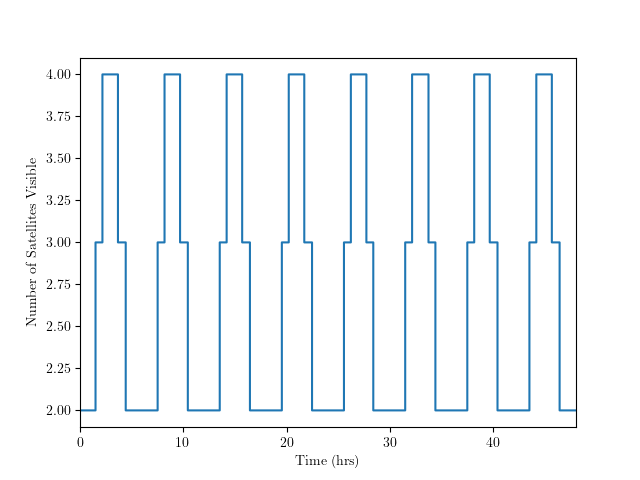

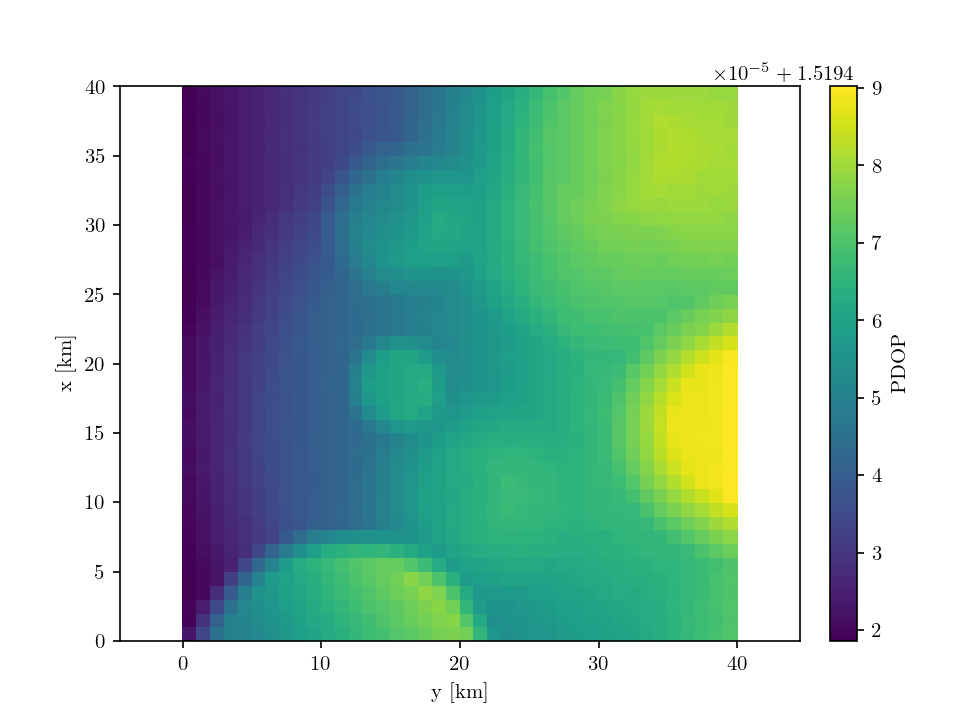

Text(0.5, 1.0, 'Time t = 3.0052 hours')

In [7]:
# get the number of satellites that are visible at each time step
# if elevation is greater than 5, then the satellite is visible
visible_sat = np.zeros((N_sat, len(tspan)))
for i_sat in range(N_sat):
    visible_sat[i_sat] = el_sat[i_sat] > 10
tot_visible = np.sum(visible_sat, axis=0)

# plot as a step function
plt.figure()
plt.step(tspan/3600, tot_visible)
plt.xlabel('Time (hrs)')
plt.ylabel('Number of Satellites Visible')
plt.xlim(0, tf/3600)
plt.show()

# fig, ax = grid_env.plot_grid_elev(t=0, param_idx=2)
t = int(N_t*3/48)
fig, ax = grid_env.plot_grid_elev(t=t, param_idx=2)
ax.set_title(f'Time t = {tspan[t]/3600:.4f} hours')

# A*

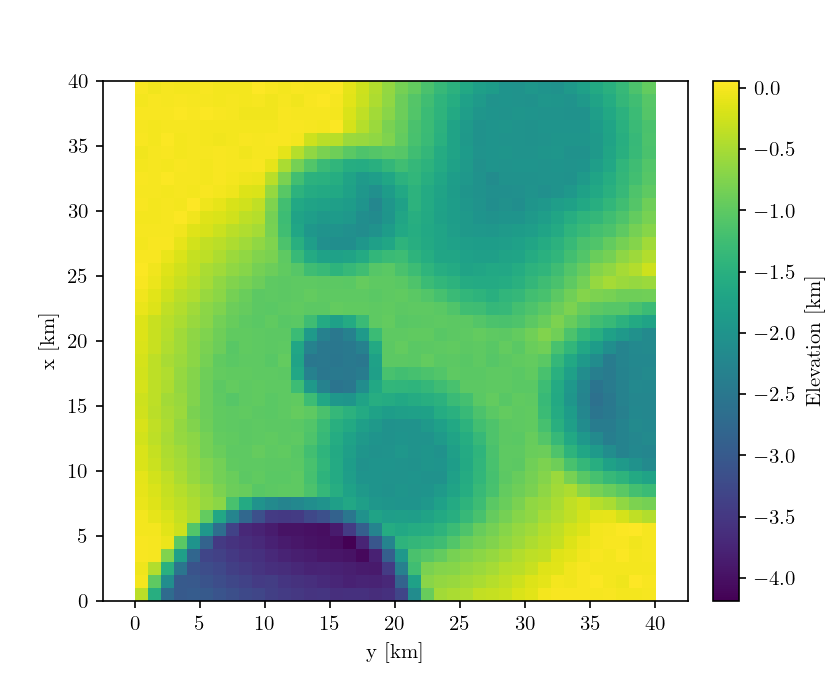

In [18]:
# what we are passing in are the initial and goal inidices in the grid
x_init_idx = [5,5]
x_goal_idx = [35,35]
# get the initial and goal states in the grid
x_init = (resolution*x_init_idx[0], resolution*x_init_idx[1])
x_goal = (resolution*x_goal_idx[0], resolution*x_goal_idx[1])

# from AA274A --> needed lower bound tuple, upper bound tuple, initial state tuple, goal state tuple, occupancy as the grid, and resolution
# obstacles = [((6,7),(8,8)),((2,2),(4,3)),((2,5),(4,7)),((6,3),(8,5))]
# obstacles = [((0,7),(15,15)), ((25,22),(40,30))]
obstacles = None
weights = [0,100]
resolution = grid_env.res
astar = AStarPlanner((0, 0), (grid_env.N, grid_env.N), x_init, x_goal, grid_env, tspan, resolution, True, obstacles, weights)

if not astar.solve():
    print("No path found")
else:
    path_plan = astar.path
    plt.rcParams['figure.figsize'] = [5.5, 4.5]
    # plt.rcParams['figure.figsize'] = [3, 3]
    fig, ax = astar.plot_path()
    # astar.plot_tree()

ax.set_title(f'Path Planning ($w_e$ = {weights[0]}, $w_p$ = {weights[1]})')
ax.set_xlabel('East')
ax.set_ylabel('North')

waypoints = astar.get_waypoints(10)
# plot the downsampled path as scatter points
ax.plot(waypoints[:,1]/resolution, waypoints[:,0]/resolution, 'ko')

In [19]:
path_time = astar.reconstruct_time(path_plan)

In [20]:
path_time/3600

array([ 1.5       ,  1.64142136,  1.74142136,  1.84142136,  1.98284271,
        2.08284271,  2.18284271,  2.28284271,  2.42426407,  2.52426407,
        2.62426407,  2.76568542,  2.86568542,  2.96568542,  3.06568542,
        3.16568542,  3.26568542,  3.36568542,  3.46568542,  3.56568542,
        3.70710678,  3.80710678,  3.94852814,  4.08994949,  4.18994949,
        4.28994949,  4.38994949,  4.53137085,  7.50612554,  7.60612554,
        7.7475469 ,  7.88896825,  7.98896825,  8.13038961,  8.27181096,
        8.37181096,  8.47181096,  8.57181096,  8.71323232,  8.81323232,
        8.91323232,  9.05465368,  9.19607503,  9.33749639,  9.47891775,
        9.57891775,  9.7203391 ,  9.8203391 ,  9.9203391 , 10.06176046,
       10.16176046, 10.30318181])

In [21]:
len(path_time)

52

In [22]:
len(path_plan)

52

In [23]:
# rv_moon_sat_pa: Number of satellites x time vector x 6-state (x, y, z, vx, vy, vz)
ground_track = np.zeros((N_sat, N_t, 2))
ma = np.deg2rad([180, 0])
ma_4 = np.tile(ma, (1, 2))

for i_sat in range(N_sat):
    for t in range(N_t):
        # 
        pos_norm = np.linalg.norm(rv_moon_sat_pa[i_sat, t, :3])
        dec = np.arcsin(rv_moon_sat_pa[i_sat, t, 2] / pos_norm)
        if (rv_moon_sat_pa[i_sat, t, 1] / pos_norm) > 0:
            r_asc = np.arccos(rv_moon_sat_pa[i_sat, t, 0] / pos_norm / np.cos(dec))
        else:
            r_asc = 2 * np.pi - np.arccos(rv_moon_sat_pa[i_sat, t, 0] / pos_norm / np.cos(dec))
        dec = np.rad2deg(dec)
        r_asc = np.rad2deg(r_asc)
        ground_track[i_sat, t, :] = (dec, r_asc) # in radians

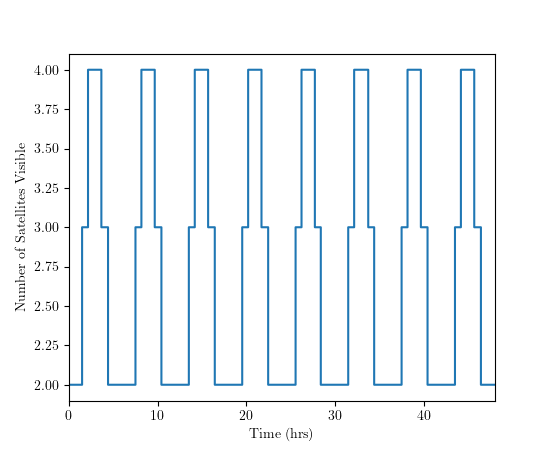

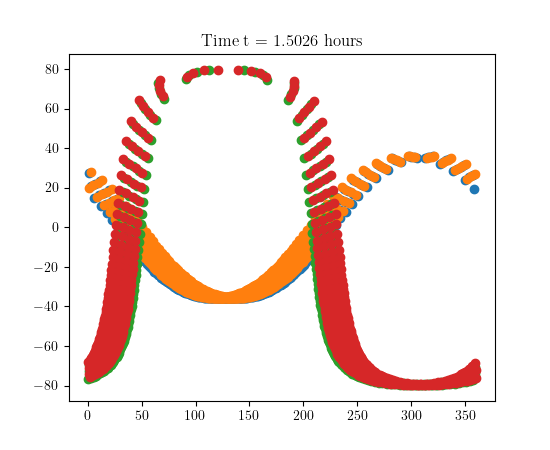

In [24]:
# get the number of satellites that are visible at each time step
# if elevation is greater than 5, then the satellite is visible

lent = len(tspan)
visible_sat = np.zeros((N_sat, lent))
for i_sat in range(N_sat):
    visible_sat[i_sat] = el_sat[i_sat] > 10
tot_visible = np.sum(visible_sat, axis=0)

# plot as a step function
plt.figure()
plt.step(tspan/3600, tot_visible)
plt.xlabel('Time (hrs)')
plt.ylabel('Number of Satellites Visible')
plt.xlim(0, tf/3600)

plt.show()

# fig, ax = grid_env.plot_grid_elev(t=0, param_idx=2)
t = int(N_t*1.5/48)
# fig, ax = grid_env.plot_grid_elev(t=t, param_idx=0, lat_long = True)
fig, ax = plt.figure(), plt.gca()
ax.set_title(f'Time t = {tspan[t]/3600:.4f} hours')
for i_sat in range(N_sat):
    plt.scatter(ground_track[i_sat, :, 1], ground_track[i_sat, :, 0])
    # plt.scatter(ground_track[i_sat, t, 1], ground_track[i_sat, t, 0], s=30, color = 'k')
    # print((ground_track[i_sat, N_t-20, 1], ground_track[i_sat, N_t-20, 0]))




In [27]:
waypoints

array([[0.5, 0.5, 0. ],
       [0.7, 0.5, 0. ],
       [1. , 1. , 0. ],
       [1.6, 1. , 0. ],
       [2.2, 1.3, 0. ],
       [2.6, 1.6, 0. ],
       [2.9, 2.2, 0. ],
       [3.2, 2.8, 0. ],
       [3.5, 3.4, 0. ],
       [3.5, 3.5, 0. ]])

In [26]:
waypoints.shape

(10, 3)